# ML4SCI Task 1: Multi-Model Lensing Classification

This notebook presents a PyTorch transfer-learning study for three-class gravitational lensing classification. The objective is to distinguish images with **no substructure**, **sphere-like substructure**, and **vortex-like substructure** using pretrained vision backbones adapted to normalized lensing maps.

The experimental pipeline combines a fresh 90:10 stratified split, `log1p` intensity scaling, geometric augmentation, grayscale-to-RGB channel repetition, and evaluation with accuracy, confusion matrices, classification reports, ROC curves, and macro ROC-AUC. To keep execution stable on Windows, dataset construction, dataloader creation, and model training are deferred to the final `if __name__ == "__main__":` block.

## Notebook Structure

The notebook is organized as a compact experimental workflow:

1. define the experimental configuration and shared constants
2. define data-loading, preprocessing, augmentation, and caching utilities
3. define model-building, optimization, training, and evaluation utilities
4. execute the full comparison across multiple pretrained backbones
5. summarize performance using both threshold-based and probability-based metrics

## Methodological Strategy

The task is approached as a **scientific transfer learning** problem rather than a conventional image-classification benchmark. The main assumptions guiding the design are:

- pretrained ImageNet backbones provide useful low-level and mid-level visual priors
- faint arcs and perturbations require intensity compression before resizing and classification
- geometric augmentation should reflect orientation invariance in lensing structure
- class probabilities matter, so ROC-AUC is treated as a first-class metric alongside accuracy

This combination is intended to preserve astrophysically meaningful structure while remaining practical to train on a local machine.

## Data and Preprocessing Setup

The following code establishes the shared experimental environment: imports, configuration, dataset indexing, tensor preprocessing, caching support, augmentation, and dataset preview logic. This section forms the input pipeline used by every model in the comparison, so keeping it centralized ensures that architectural differences are evaluated under the same data conditions.

In [ ]:
import random
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from torch.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset
from torchvision.models import (
    EfficientNet_V2_S_Weights,
    MaxVit_T_Weights,
    ResNet50_Weights,
    efficientnet_v2_s,
    maxvit_t,
    resnet50,
)
from torchvision.transforms import InterpolationMode
from torchvision.transforms import functional as TF
from tqdm.auto import tqdm


### `Config`: Experimental Configuration
This cell defines the global experiment configuration, including dataset locations, image resolution, training schedule, optimization defaults, AMP settings, and per-model checkpoint metadata. Keeping these values together makes the notebook easier to reproduce and ensures that backbone comparisons are driven by controlled changes rather than hidden defaults.

In [2]:
@dataclass
class Config:
    root_dir: Path = Path("dataset")
    fast_root_dir: Path = Path("dataset_fast_224")
    build_fast_dataset_if_missing: bool = True
    force_rebuild_fast_dataset: bool = False
    seed: int = 42
    train_ratio: float = 0.9
    image_size: int = 224
    num_workers: int = 0
    num_classes: int = 3
    epochs: int = 15
    learning_rate: float = 1e-4
    weight_decay: float = 1e-4
    use_amp: bool = torch.cuda.is_available()
    amp_device: str = "cuda" if torch.cuda.is_available() else "cpu"


config = Config()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_names = ["no", "sphere", "vort"]
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
experiment_settings = {
    "efficientnet_v2_s": {
        "display_name": "EfficientNetV2-S",
        "batch_size": 128,
        "checkpoint": "best_efficientnet_v2_s_lensing.pt",
    },
    "resnet50": {
        "display_name": "ResNet50",
        "batch_size": 128,
        "checkpoint": "best_resnet50_lensing.pt",
    },
    "maxvit_t": {
        "display_name": "MaxVit-T",
        "batch_size": 64,
        "checkpoint": "best_maxvit_t_lensing.pt",
    },
}


### `set_seed`: Reproducibility Control
This helper fixes the random state for Python, NumPy, and PyTorch. Its purpose is to reduce run-to-run variance so that observed differences between backbones are more likely to reflect the models themselves rather than stochastic initialization effects.

In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


### `collect_raw_records`: Dataset Index Construction
This function scans the raw dataset folders and converts them into a dataframe of file paths, labels, class names, and split identifiers. It serves as the structured representation of the dataset used throughout the rest of the notebook.

In [4]:
def collect_raw_records(root_dir):
    root_dir = Path(root_dir)
    rows = []
    for split_name in ["train", "val"]:
        for class_name in class_names:
            for file_path in sorted((root_dir / split_name / class_name).glob("*.npy")):
                rows.append(
                    {
                        "split_name": split_name,
                        "class_name": class_name,
                        "target": class_to_idx[class_name],
                        "data_path": str(file_path),
                        "original_path": str(file_path),
                        "file_type": "npy",
                    }
                )
    return pd.DataFrame(rows)


### `fast_dataset_ready`: Cache Availability Check
This helper determines whether the preprocessed tensor cache already exists and is complete. Its role is to avoid unnecessary regeneration of the fast dataset and to allow the notebook to switch automatically between raw `.npy` inputs and cached `.pt` tensors.

In [5]:
def fast_dataset_ready(fast_root_dir, expected_count=None):
    fast_root_dir = Path(fast_root_dir)
    if not fast_root_dir.exists():
        return False
    pt_files = list(fast_root_dir.rglob("*.pt"))
    if not pt_files:
        return False
    if expected_count is not None and len(pt_files) < expected_count:
        return False
    return True


### `collect_records`: Unified Data Source Selection
This function wraps raw record collection and, when available, replaces raw file paths with cached tensor paths. It provides a single dataframe interface regardless of whether the run is using the original dataset or the accelerated cache.

In [6]:
def collect_records(root_dir, fast_root_dir=None):
    raw_df = collect_raw_records(root_dir)
    if fast_root_dir is None:
        return raw_df

    fast_root_dir = Path(fast_root_dir)
    rows = []
    for row in raw_df.to_dict("records"):
        original_path = Path(row["original_path"])
        fast_path = fast_root_dir / row["split_name"] / row["class_name"] / f"{original_path.stem}.pt"
        if fast_path.exists():
            row["data_path"] = str(fast_path)
            row["file_type"] = "pt"
        rows.append(row)
    return pd.DataFrame(rows)


### `preprocess_array`: Physical Signal Preparation
This is the core preprocessing routine for a single lensing map. It applies `log1p` scaling, rescales the intensity range, and resizes the image to the target resolution. The goal is to make faint lensing structure more visible to pretrained backbones without discarding global morphology.

In [7]:
def preprocess_array(array):
    image = np.squeeze(array).astype(np.float32)
    image = np.clip(image, 0.0, None)
    image = np.log1p(image)
    image -= image.min()
    max_value = image.max()
    if max_value > 0:
        image /= max_value
    tensor = torch.from_numpy(image).unsqueeze(0)
    tensor = TF.resize(
        tensor,
        [config.image_size, config.image_size],
        interpolation=InterpolationMode.BILINEAR,
        antialias=True,
    )
    return tensor


### `save_fast_dataset`: Precomputed Tensor Cache
This helper preprocesses the raw dataset once and stores the resized tensors as `.pt` files. Its purpose is computational rather than scientific: expensive CPU-side preprocessing is moved out of the training loop so later experiments run much faster, especially in Windows notebook environments.

In [8]:
def save_fast_dataset(dataframe, output_root):
    output_root = Path(output_root)
    output_root.mkdir(parents=True, exist_ok=True)
    print(f"Pre-processing {len(dataframe)} images to {output_root}...")

    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        original_path = Path(row["original_path"])
        processed_tensor = preprocess_array(np.load(original_path).astype(np.float32))
        target_dir = output_root / row["split_name"] / row["class_name"]
        target_dir.mkdir(parents=True, exist_ok=True)
        torch.save(processed_tensor, target_dir / f"{original_path.stem}.pt")


### `augment_tensor`: Physics-Aware Augmentation
This function applies the training-time geometric augmentation policy. Rotations, flips, and moderate scaling are used because the classification target should be invariant to image orientation while still benefiting from exposure to spatial variability.

In [9]:
def augment_tensor(tensor):
    tensor = TF.affine(
        tensor,
        angle=random.uniform(-180, 180),
        translate=[0, 0],
        scale=random.uniform(0.9, 1.1),
        shear=[0.0, 0.0],
        interpolation=InterpolationMode.BILINEAR,
        fill=0.0,
    )
    if random.random() < 0.5:
        tensor = TF.hflip(tensor)
    if random.random() < 0.5:
        tensor = TF.vflip(tensor)
    return tensor.clamp(0.0, 1.0)


### `DatasetNPY`: Sample Loading Interface
This dataset class is the unified loader for both raw `.npy` files and cached `.pt` tensors. It handles caching, optional augmentation, grayscale-to-RGB channel repetition, and final normalization, making it the main interface between indexed files and the PyTorch training loop.

In [10]:
class DatasetNPY(Dataset):
    def __init__(self, dataframe, augment=False):
        self.dataframe = dataframe.reset_index(drop=True)
        self.augment = augment
        self.cache = {}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        path = Path(row["data_path"])
        cache_key = str(path)

        if cache_key not in self.cache:
            if path.suffix == ".pt":
                self.cache[cache_key] = torch.load(path, map_location="cpu").float()
            else:
                raw_data = np.load(path).astype(np.float32)
                self.cache[cache_key] = preprocess_array(raw_data)

        img = self.cache[cache_key].clone()
        if self.augment:
            img = augment_tensor(img)
        img = img.repeat(3, 1, 1)
        img = TF.normalize(img, mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        label = torch.tensor(row["target"]).long()
        return img, label


### `preview_dataset`: Sanity Check Visualization
This helper reports class counts, file-source usage, and one representative tensor preview. It is used as a quick validation step before training to confirm that the pipeline is reading the expected inputs and producing correctly shaped tensors.

In [11]:
def preview_dataset(dataframe):
    print("Total samples:", len(dataframe))
    print(dataframe["class_name"].value_counts().sort_index())
    print("Source files used:")
    print(dataframe["file_type"].value_counts().sort_index())
    if len(dataframe) == 0:
        return

    sample_path = Path(dataframe.iloc[0]["data_path"])
    if sample_path.suffix == ".pt":
        sample_tensor = torch.load(sample_path, map_location="cpu").float().repeat(3, 1, 1)
    else:
        sample = np.load(sample_path).astype(np.float32)
        sample_tensor = preprocess_array(sample).repeat(3, 1, 1)

    print("Sample tensor shape:", sample_tensor.shape)
    plt.figure(figsize=(4, 4))
    plt.imshow(sample_tensor[0], cmap="gray")
    plt.title(f"{dataframe.iloc[0]['class_name']} ({dataframe.iloc[0]['file_type']})")
    plt.axis("off")
    plt.show()


## Model Definitions and Training Utilities

This section defines the shared model-building and training components used across experiments. The notebook compares multiple pretrained backbones under a common optimization and evaluation pipeline so that model differences can be interpreted more cleanly.

## Evaluation Design

The evaluation code is designed to answer two related questions:

- **How accurate is each model as a classifier?**
- **How well separated are the predicted class probabilities?**

For that reason, the notebook records loss, accuracy, confusion matrices, classification reports, per-class ROC curves, and macro ROC-AUC. This is especially important for lensing applications, where calibrated class separation is often more informative than a single hard prediction.

### `replace_last_linear`: Head Adaptation Utility
Some pretrained architectures expose their final classifier through nested sequential blocks rather than a single attribute. This helper locates the last linear layer and replaces it so the backbone can be adapted cleanly to the three DeepLense classes.

In [12]:
def replace_last_linear(seq, num_classes):
    layers = list(seq.children())
    for i in range(len(layers) - 1, -1, -1):
        if isinstance(layers[i], nn.Linear):
            layers[i] = nn.Linear(layers[i].in_features, num_classes)
            break
    return nn.Sequential(*layers)


### `build_model`: Backbone Factory
This function constructs the requested pretrained backbone and rewires its classification head for the current task. It makes the architectural comparison explicit while keeping the rest of the notebook independent of model-specific details.

In [13]:
def build_model(model_name):
    if model_name == "efficientnet_v2_s":
        model = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, config.num_classes)
    elif model_name == "resnet50":
        model = resnet50(weights=ResNet50_Weights.DEFAULT)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, config.num_classes),
        )
    elif model_name == "maxvit_t":
        model = maxvit_t(weights=MaxVit_T_Weights.DEFAULT)
        model.classifier = replace_last_linear(model.classifier, config.num_classes)
    else:
        raise ValueError("Unknown model name")
    return model.to(device)


### `build_dataloaders`: Batch Construction
This helper creates the training and validation dataloaders. Centralizing dataloader settings such as batch size, worker count, memory pinning, and worker persistence makes performance tuning easier and keeps experimental conditions consistent across models.

In [14]:
def build_dataloaders(train_dataset, val_dataset, batch_size):
    loader_kwargs = {
        "num_workers": config.num_workers,
        "pin_memory": True,
    }
    if config.num_workers > 0:
        loader_kwargs["persistent_workers"] = True
        loader_kwargs["prefetch_factor"] = 2
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        **loader_kwargs,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        **loader_kwargs,
    )
    return train_loader, val_loader


### `build_optimizer`: Optimization Setup
This function bundles the loss function, optimizer, scheduler, and AMP scaler into a single setup step. Using one shared optimization recipe helps keep the backbone comparison fair and reduces duplicated configuration logic.

In [15]:
def build_optimizer(model):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.3, patience=2)
    scaler = GradScaler(config.amp_device, enabled=config.use_amp)
    return criterion, optimizer, scheduler, scaler


### `train_epoch`: One Training Pass
This helper performs one full training epoch, including mixed-precision forward passes, backpropagation, optimizer updates, and running accuracy/loss tracking. It isolates the mechanics of training from the higher-level experiment loop.

In [16]:
def train_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(loader, desc="Train", leave=False):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        with autocast(device_type=config.amp_device, enabled=config.use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / len(loader.dataset), correct / total


### `validate`: Probability-Based Evaluation
This function evaluates a model without gradient updates and returns both label predictions and class probabilities. Its role is central because the notebook needs numerically stable probability outputs for ROC curves and multiclass ROC-AUC, not just top-1 predictions.

In [17]:
def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    probs, labels_all, preds = [], [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validate", leave=False):
            images = images.to(device)
            labels = labels.to(device)
            with autocast(device_type=config.amp_device, enabled=config.use_amp):
                outputs = model(images)
                loss = criterion(outputs, labels)
            prob = torch.softmax(outputs.float(), dim=1)
            prob = prob / prob.sum(dim=1, keepdim=True)
            pred = torch.argmax(prob, dim=1)
            running_loss += loss.item() * images.size(0)
            total += labels.size(0)
            correct += pred.eq(labels).sum().item()
            probs.extend(prob.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())
            preds.extend(pred.cpu().numpy())
    probs = np.asarray(probs, dtype=np.float32)
    probs = probs / probs.sum(axis=1, keepdims=True)
    labels_all = np.asarray(labels_all)
    preds = np.asarray(preds)
    acc = correct / total
    macro_auc = roc_auc_score(labels_all, probs, multi_class="ovr", average="macro")
    return running_loss / len(loader.dataset), acc, probs, labels_all, preds, macro_auc


### `plot_history`: Convergence Visualization
This plotting helper shows how loss and accuracy evolve across epochs. It provides a compact visual summary of convergence behavior and is useful for spotting instability or overfitting.

In [18]:
def plot_history(history, name):
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.title(f"{name} Loss")
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history["train_acc"], label="Train Acc")
    plt.plot(history["val_acc"], label="Val Acc")
    plt.title(f"{name} Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()


### `plot_confusion`: Error Structure Visualization
This helper plots the confusion matrix for a trained model. It is useful for identifying which classes are most often confused with one another, especially for neighboring scientific categories such as `sphere` and `vort`.

In [19]:
def plot_confusion(labels, preds, title):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


### `plot_roc`: One-vs-Rest ROC Analysis
This function draws one-vs-rest ROC curves for the validation set. It complements accuracy with a threshold-independent view of class separation and directly supports the task emphasis on AUC.

In [20]:
def plot_roc(labels, probs, title):
    labels_bin = label_binarize(labels, classes=[0, 1, 2])
    plt.figure(figsize=(8, 6))
    for i, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(labels_bin[:, i], probs[:, i])
        class_auc = roc_auc_score(labels_bin[:, i], probs[:, i])
        plt.plot(fpr, tpr, label=f"{class_name} AUC={class_auc:.3f}")
    plt.plot([0, 1], [0, 1], "k--", lw=2, label="Chance")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


### `plot_train_val_roc`: Generalization Comparison
This helper overlays train and validation ROC curves for each class. It provides a visual check on whether the probability structure learned during training is carrying over to unseen validation data.

In [21]:
def plot_train_val_roc(train_labels, train_probs, val_labels, val_probs, title):
    train_bin = label_binarize(train_labels, classes=[0, 1, 2])
    val_bin = label_binarize(val_labels, classes=[0, 1, 2])
    plt.figure(figsize=(10, 8))
    for i, class_name in enumerate(class_names):
        fpr_train, tpr_train, _ = roc_curve(train_bin[:, i], train_probs[:, i])
        auc_train = roc_auc_score(train_bin[:, i], train_probs[:, i])
        plt.plot(fpr_train, tpr_train, "--", label=f"Train {class_name} AUC = {auc_train:.3f}")
        fpr_val, tpr_val, _ = roc_curve(val_bin[:, i], val_probs[:, i])
        auc_val = roc_auc_score(val_bin[:, i], val_probs[:, i])
        plt.plot(fpr_val, tpr_val, "-", label=f"Val {class_name} AUC = {auc_val:.3f}")
    plt.plot([0, 1], [0, 1], "k--", lw=2, label="Chance level")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


### `summarize_results`: Compact Metrics Table
This function packages the main outputs of an experiment into a small summary table. It is intended to make the notebook easier to read and to provide values that can be quoted directly in the report narrative.

In [22]:
def summarize_results(results):
    labels_bin = label_binarize(results["val_labels"], classes=[0, 1, 2])
    aucs = {
        name: roc_auc_score(labels_bin[:, i], results["val_probs"][:, i])
        for i, name in enumerate(class_names)
    }
    return pd.DataFrame(
        {
            "Metric": [
                "Model",
                "Epochs",
                "Batch Size",
                "Optimizer",
                "Learning Rate",
                "Scheduler",
                "Final Train Accuracy",
                "Final Validation Accuracy",
                "Best Validation Accuracy",
                "Final Train Loss",
                "Final Validation Loss",
                "AUC (no)",
                "AUC (sphere)",
                "AUC (vort)",
                "Macro AUC",
            ],
            "Value": [
                results["display_name"],
                config.epochs,
                results["batch_size"],
                "Adam",
                config.learning_rate,
                "ReduceLROnPlateau",
                f"{results['history']['train_acc'][-1] * 100:.2f}%",
                f"{results['history']['val_acc'][-1] * 100:.2f}%",
                f"{max(results['history']['val_acc']) * 100:.2f}% (Epoch {np.argmax(results['history']['val_acc']) + 1})",
                f"{results['history']['train_loss'][-1]:.4f}",
                f"{results['history']['val_loss'][-1]:.4f}",
                f"{aucs['no']:.4f}",
                f"{aucs['sphere']:.4f}",
                f"{aucs['vort']:.4f}",
                f"{results['val_auc']:.4f}",
            ],
        }
    )


### `print_auc_scores`: Numerical ROC-AUC Report
This helper prints per-class and macro AUC values in a clean textual format. It complements the ROC figures with exact numbers for comparison and interpretation.

In [23]:
def print_auc_scores(results):
    labels_bin = label_binarize(results["val_labels"], classes=[0, 1, 2])
    print(f"--- {results['display_name']} AUC Scores (Validation Set) ---")
    for i, class_name in enumerate(class_names):
        class_auc = roc_auc_score(labels_bin[:, i], results["val_probs"][:, i])
        print(f"AUC for class {class_name}: {class_auc:.4f}")
    print(f"Overall AUC (Macro Average): {results['val_auc']:.4f}")


### `train_model`: Single-Backbone Experiment Loop
This is the main training routine for one backbone. It connects model construction, dataloaders, optimization, checkpointing, and best-weight reloading into one reusable experiment function.

In [24]:
def train_model(model_name, train_dataset, val_dataset):
    settings = experiment_settings[model_name]
    model = build_model(model_name)
    train_loader, val_loader = build_dataloaders(train_dataset, val_dataset, settings["batch_size"])
    criterion, optimizer, scheduler, scaler = build_optimizer(model)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_auc": []}
    best_auc = -np.inf
    for epoch in range(config.epochs):
        print(f"Epoch {epoch + 1}")
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, scaler)
        val_loss, val_acc, probs, labels, preds, val_auc = validate(model, val_loader, criterion)
        scheduler.step(val_loss)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_auc"].append(val_auc)
        print("Train Loss:", train_loss, "Train Acc:", train_acc)
        print("Val Loss:", val_loss, "Val Acc:", val_acc, "Val AUC:", val_auc)
        if val_auc > best_auc:
            best_auc = val_auc
            torch.save({"model_state_dict": model.state_dict()}, settings["checkpoint"])
    best_model = build_model(model_name)
    best_model.load_state_dict(torch.load(settings["checkpoint"], map_location=device)["model_state_dict"])
    train_loss, train_acc, train_probs, train_labels, train_preds, train_auc = validate(best_model, train_loader, criterion)
    val_loss, val_acc, val_probs, val_labels, val_preds, val_auc = validate(best_model, val_loader, criterion)
    return {
        "model": best_model,
        "display_name": settings["display_name"],
        "batch_size": settings["batch_size"],
        "history": history,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_probs": train_probs,
        "train_labels": train_labels,
        "train_preds": train_preds,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_probs": val_probs,
        "val_labels": val_labels,
        "val_preds": val_preds,
        "val_auc": val_auc,
    }


### `run_experiment`: Full Results Pipeline
This wrapper executes a full experiment and then produces the notebook outputs for that model: summary table, learning curves, confusion matrix, ROC plots, and printed classification metrics. It keeps the final execution block concise while preserving a complete results presentation.

In [25]:
def run_experiment(model_name, train_dataset, val_dataset):
    results = train_model(model_name, train_dataset, val_dataset)
    summary = summarize_results(results)
    display(summary)
    plot_history(results["history"], results["display_name"])
    plot_confusion(results["val_labels"], results["val_preds"], f"{results['display_name']} Confusion Matrix")
    plot_roc(results["val_labels"], results["val_probs"], f"{results['display_name']} ROC Curves")
    plot_train_val_roc(
        results["train_labels"],
        results["train_probs"],
        results["val_labels"],
        results["val_probs"],
        f"{results['display_name']} ROC Curve - Train vs Validation",
    )
    print(f"--- {results['display_name']} Classification Report (Validation Set) ---")
    print(classification_report(results["val_labels"], results["val_preds"], target_names=class_names))
    print(f"Overall Validation Accuracy: {results['val_acc']:.4f}")
    print_auc_scores(results)
    return results, summary


## Execution Notes
The final block below performs the actual experiment: dataset discovery, optional cache creation, train/validation splitting, model training, and final comparison. Keeping execution at the end of the notebook makes the workflow easier to rerun from top to bottom and keeps the earlier sections focused on methodology.

# Final Execution Block

Using device: cuda
AMP enabled: True
Fast dataset found at dataset_fast_224. Using preprocessed .pt tensors.
Total samples: 31936
class_name
no        10000
sphere    10000
vort      11936
Name: count, dtype: int64
Source files used:
file_type
pt    31936
Name: count, dtype: int64
Sample tensor shape: torch.Size([3, 224, 224])


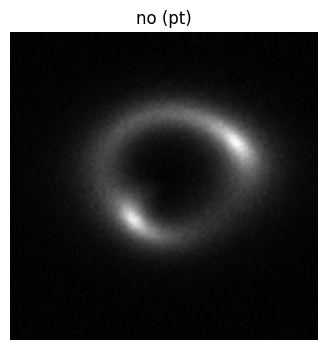

Train samples: 28742
Validation samples: 3194
class_name
no         9000
sphere     9000
vort      10742
Name: count, dtype: int64
class_name
no        1000
sphere    1000
vort      1194
Name: count, dtype: int64
Training sources:
file_type
pt    28742
Name: count, dtype: int64
Validation sources:
file_type
pt    3194
Name: count, dtype: int64
Epoch 1


Train Loss: 0.9683520116783467 Train Acc: 0.48789228307007165
Val Loss: 0.6877869995743615 Val Acc: 0.697871008140263 Val AUC: 0.8690708473747243
Epoch 2


Train Loss: 0.5343447001324957 Train Acc: 0.7776424744276669
Val Loss: 0.4300001037815025 Val Acc: 0.8299937382592361 Val AUC: 0.9466342971568059
Epoch 3


Train Loss: 0.38225855680964005 Train Acc: 0.8524111056989772
Val Loss: 0.327056120766202 Val Acc: 0.8725735754539762 Val AUC: 0.9690293251937802
Epoch 4


Train Loss: 0.31086589632825823 Train Acc: 0.8811843295525712
Val Loss: 0.26714359609201394 Val Acc: 0.9026299311208515 Val AUC: 0.978069952848411
Epoch 5


...

Train Loss: 0.16841310317324212 Train Acc: 0.9392874539002157
Val Loss: 0.15118081877958647 Val Acc: 0.9480275516593613 Val AUC: 0.9915397006810616
Epoch 13


Train Loss: 0.1574572819297991 Train Acc: 0.946002365875722
Val Loss: 0.15492570833183483 Val Acc: 0.9464621164683782 Val AUC: 0.9911387316151302
Epoch 14


Train Loss: 0.15199956234624096 Train Acc: 0.9464198733560643
Val Loss: 0.19314710429182036 Val Acc: 0.9383218534752661 Val AUC: 0.9917044523234017
Epoch 15


Train Loss: 0.14673229081256928 Train Acc: 0.9497599331988031
Val Loss: 0.12951620209567907 Val Acc: 0.9577332498434565 Val AUC: 0.9939949162148226


,Metric,Value
0,Model,EfficientNetV2-S
1,Epochs,15
2,Batch Size,128
3,Optimizer,Adam
4,Learning Rate,0.0001
5,Scheduler,ReduceLROnPlateau
6,Final Train Accuracy,94.98%
7,Final Validation Accuracy,95.77%
8,Best Validation Accuracy,95.77% (Epoch 15)
9,Final Train Loss,0.1467


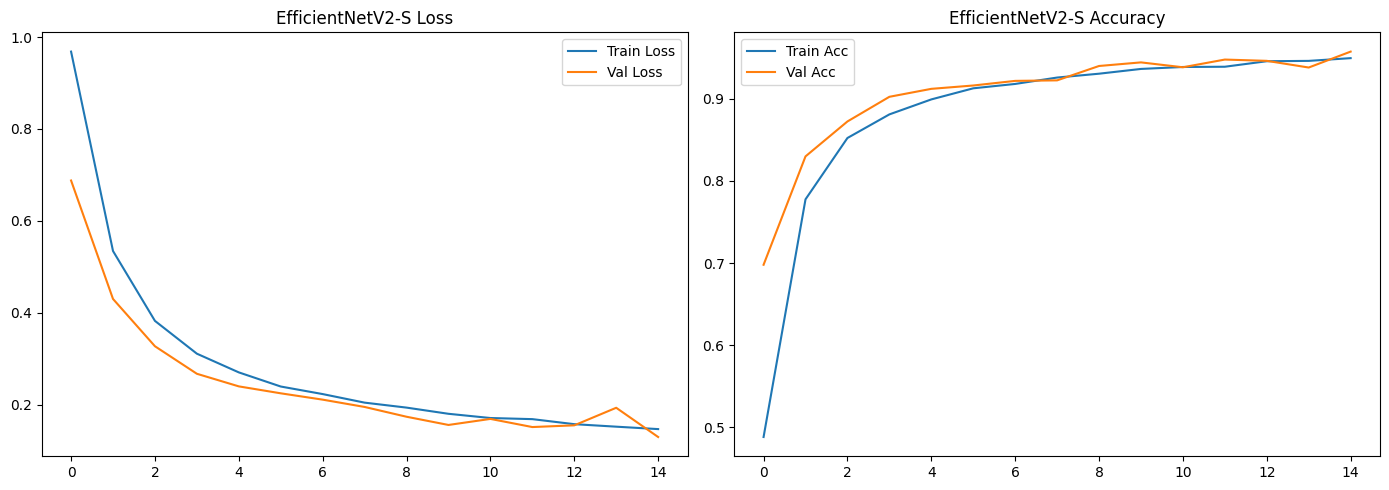

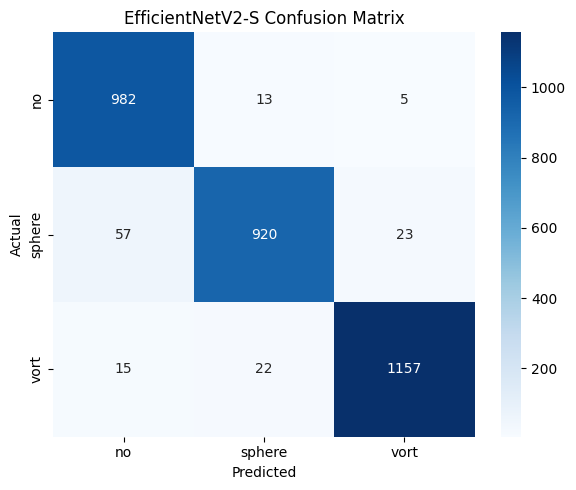

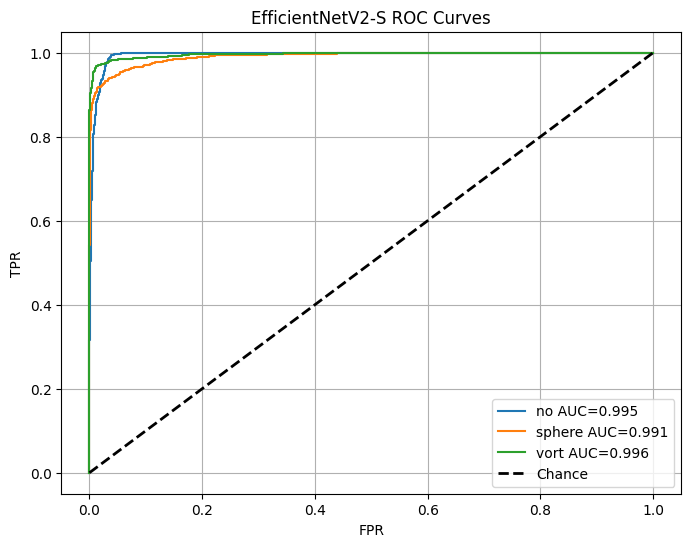

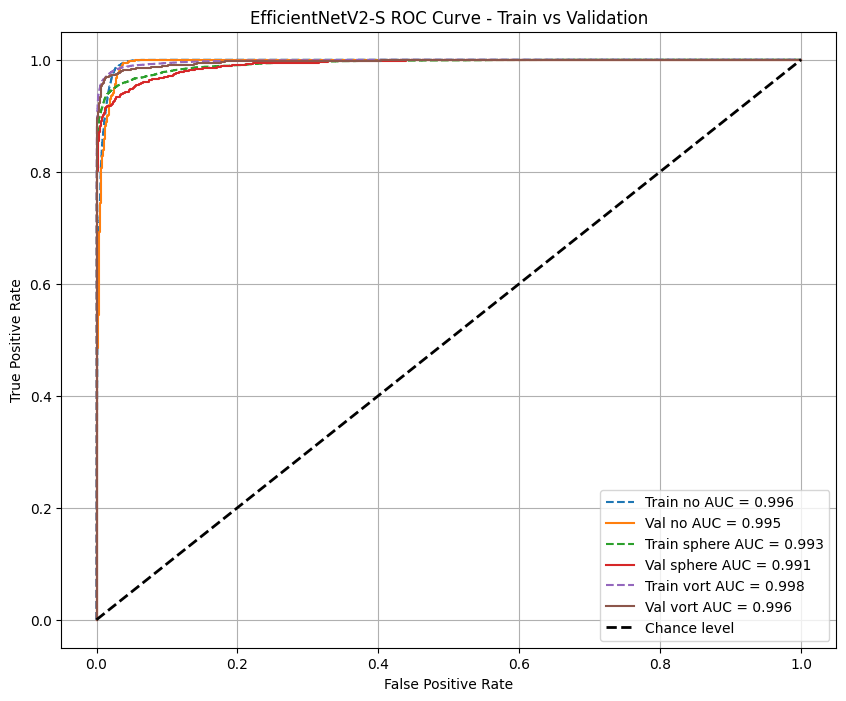

--- EfficientNetV2-S Classification Report (Validation Set) ---
              precision    recall  f1-score   support

          no       0.93      0.98      0.96      1000
      sphere       0.96      0.92      0.94      1000
        vort       0.98      0.97      0.97      1194

    accuracy                           0.96      3194
   macro avg       0.96      0.96      0.96      3194
weighted avg       0.96      0.96      0.96      3194

Overall Validation Accuracy: 0.9577
--- EfficientNetV2-S AUC Scores (Validation Set) ---
AUC for class no: 0.9948
AUC for class sphere: 0.9909
AUC for class vort: 0.9963
Overall AUC (Macro Average): 0.9940
Epoch 1


Train Loss: 1.1848393773478478 Train Acc: 0.3452786862431285
Val Loss: 1.1670469952585105 Val Acc: 0.365372573575454 Val AUC: 0.5120679710209103
Epoch 2


Train Loss: 1.1087707578285644 Train Acc: 0.39927632036740657
Val Loss: 1.0632258468519244 Val Acc: 0.4292423293675642 Val AUC: 0.6219584899072492
Epoch 3


Train Loss: 0.9339352140437586 Train Acc: 0.5417855403242642
Val Loss: 0.8579610502563123 Val Acc: 0.6048841577958672 Val AUC: 0.7976072545956767
Epoch 4


Train Loss: 0.6942757603462035 Train Acc: 0.6997425370537889
Val Loss: 0.6601357199881476 Val Acc: 0.7138384470882906 Val AUC: 0.8837042783806606
Epoch 5


...

Train Loss: 0.23999531680065989 Train Acc: 0.9131236517987614
Val Loss: 0.2718731076663632 Val Acc: 0.9020037570444583 Val AUC: 0.9800218359853557
Epoch 13


Train Loss: 0.2324930735797708 Train Acc: 0.9152807737805302
Val Loss: 0.22582756601502615 Val Acc: 0.91296180338134 Val AUC: 0.9851468920364
Epoch 14


Train Loss: 0.22455822117069338 Train Acc: 0.9178554032426415
Val Loss: 0.23458124696275331 Val Acc: 0.9092047589229806 Val AUC: 0.9846860418775739
Epoch 15


Train Loss: 0.21139146892646685 Train Acc: 0.9235265465172917
Val Loss: 0.24479508707877168 Val Acc: 0.9107701941139636 Val AUC: 0.9853579036680413


,Metric,Value
0,Model,ResNet50
1,Epochs,15
2,Batch Size,128
3,Optimizer,Adam
4,Learning Rate,0.0001
5,Scheduler,ReduceLROnPlateau
6,Final Train Accuracy,92.35%
7,Final Validation Accuracy,91.08%
8,Best Validation Accuracy,91.30% (Epoch 13)
9,Final Train Loss,0.2114


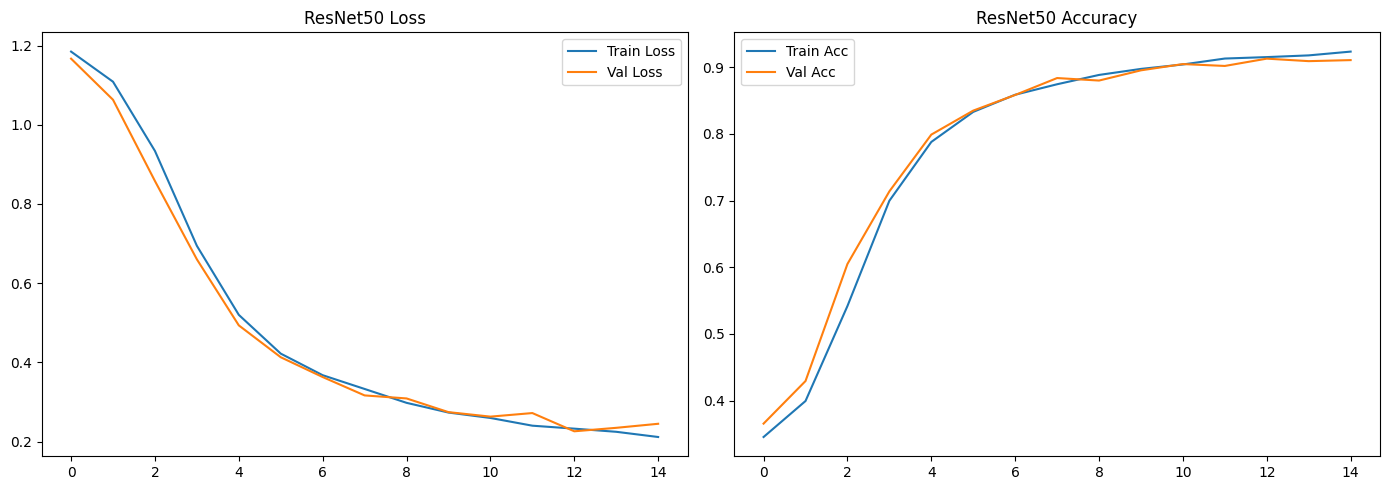

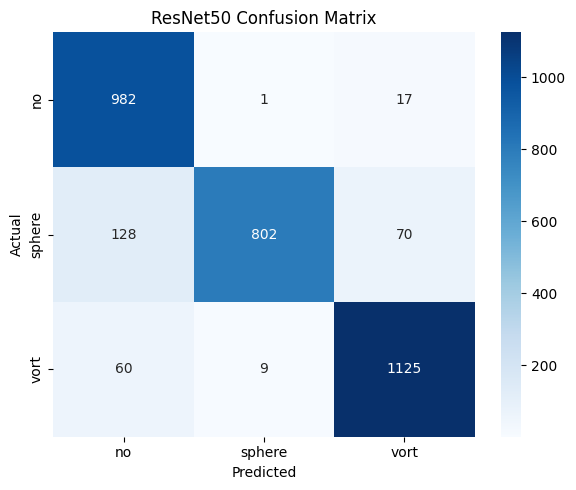

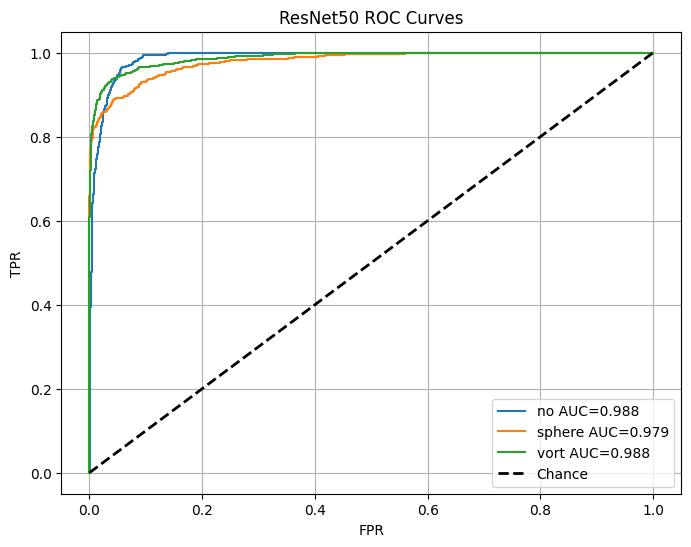

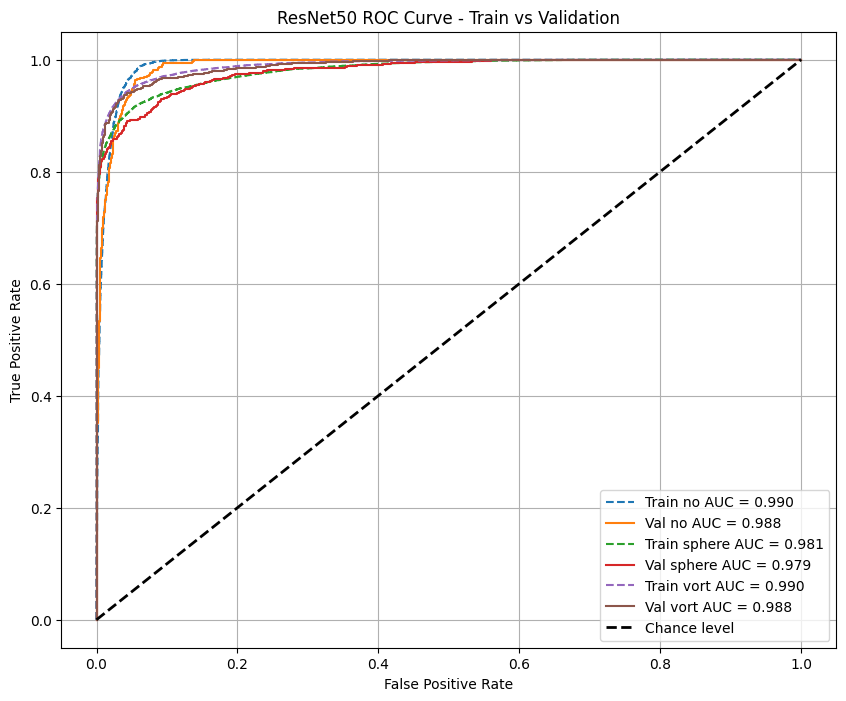

--- ResNet50 Classification Report (Validation Set) ---
              precision    recall  f1-score   support

          no       0.84      0.98      0.91      1000
      sphere       0.99      0.80      0.89      1000
        vort       0.93      0.94      0.94      1194

    accuracy                           0.91      3194
   macro avg       0.92      0.91      0.91      3194
weighted avg       0.92      0.91      0.91      3194

Overall Validation Accuracy: 0.9108
--- ResNet50 AUC Scores (Validation Set) ---
AUC for class no: 0.9883
AUC for class sphere: 0.9794
AUC for class vort: 0.9884
Overall AUC (Macro Average): 0.9854
Epoch 1


Train Loss: 0.8447535646680534 Train Acc: 0.5713241945584858
Val Loss: 0.6285235639953135 Val Acc: 0.7582968065122104 Val AUC: 0.9065571693929996
Epoch 2


Train Loss: 0.41752031944247825 Train Acc: 0.8363022754157678
Val Loss: 0.3538510533669029 Val Acc: 0.8622417031934878 Val AUC: 0.9651357950748373
Epoch 3


Train Loss: 0.3211119578769308 Train Acc: 0.8778790619998609
Val Loss: 0.3027505815663633 Val Acc: 0.8860363180964308 Val AUC: 0.9726788538560319
Epoch 4


Train Loss: 0.2757083761960913 Train Acc: 0.8979542133463224
Val Loss: 0.29336680284349637 Val Acc: 0.8800876643706951 Val AUC: 0.9801431868142494
Epoch 5


...

Train Loss: 0.1535284588366558 Train Acc: 0.9464894579361214
Val Loss: 0.1485882190172196 Val Acc: 0.9489668127739511 Val AUC: 0.9921663650980518
Epoch 13


Train Loss: 0.14459183831323902 Train Acc: 0.9494120102985178
Val Loss: 0.1741198548836005 Val Acc: 0.9383218534752661 Val AUC: 0.9907733844193113
Epoch 14


Train Loss: 0.1446548187277657 Train Acc: 0.950212232969174
Val Loss: 0.1425849919766654 Val Acc: 0.9536631183469004 Val AUC: 0.9940154231351226
Epoch 15


Train Loss: 0.13958004117232364 Train Acc: 0.9530304084614849
Val Loss: 0.13024783687772196 Val Acc: 0.9567939887288667 Val AUC: 0.9936166284170778


,Metric,Value
0,Model,MaxVit-T
1,Epochs,15
2,Batch Size,64
3,Optimizer,Adam
4,Learning Rate,0.0001
5,Scheduler,ReduceLROnPlateau
6,Final Train Accuracy,95.30%
7,Final Validation Accuracy,95.68%
8,Best Validation Accuracy,95.68% (Epoch 15)
9,Final Train Loss,0.1396


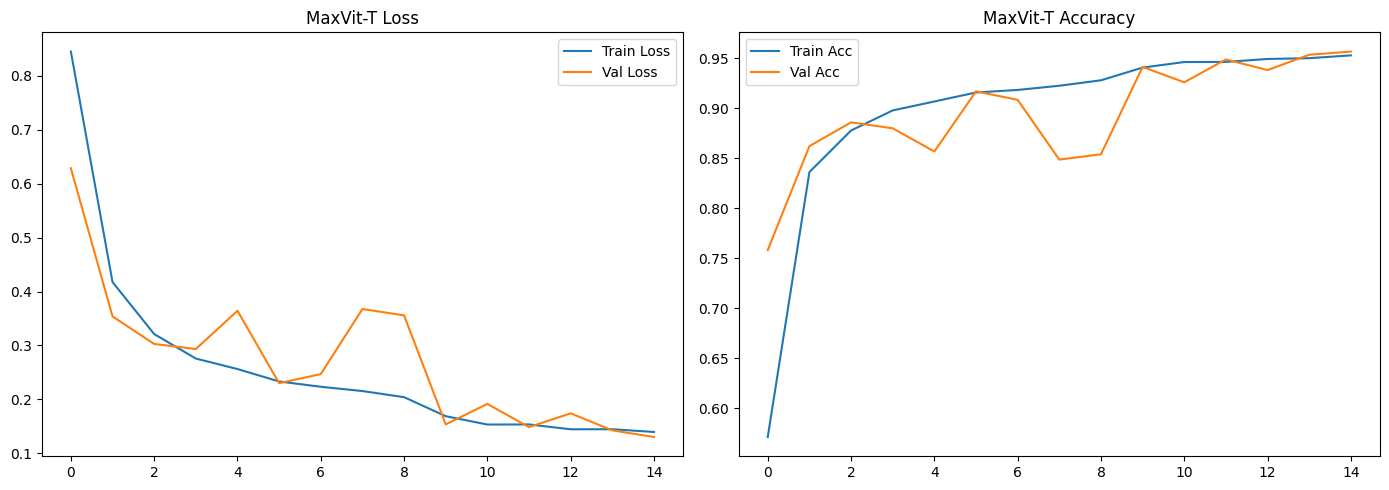

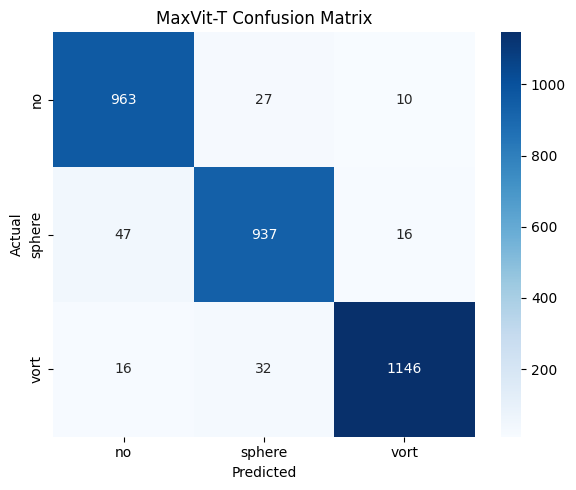

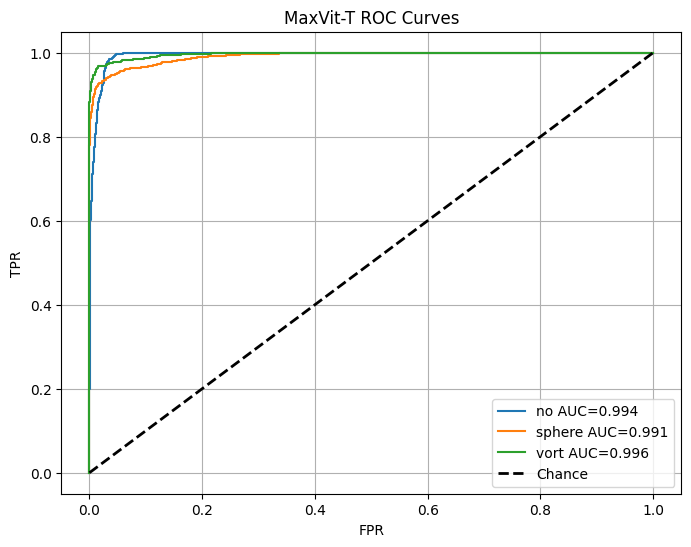

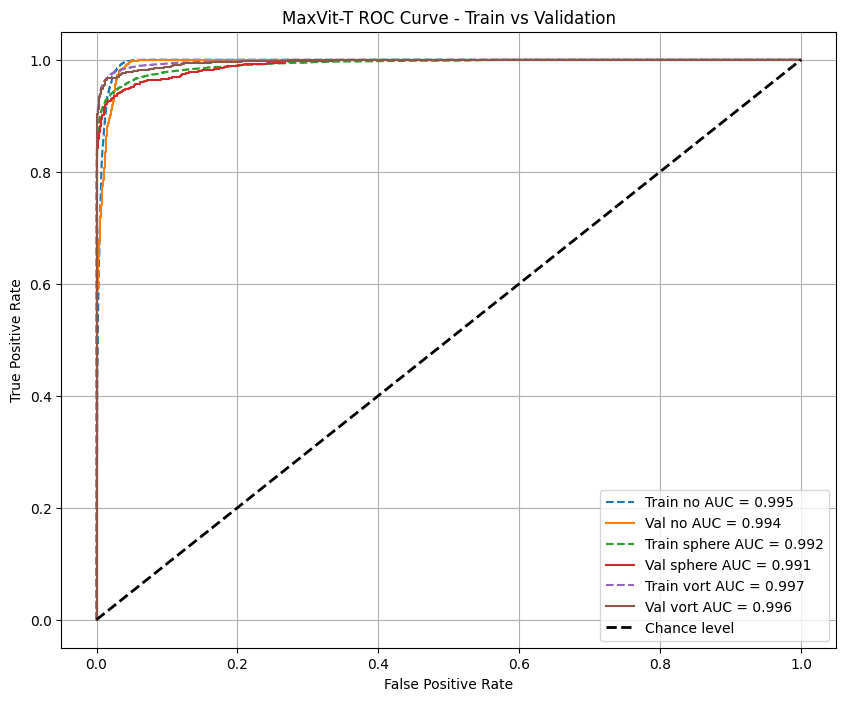

--- MaxVit-T Classification Report (Validation Set) ---
              precision    recall  f1-score   support

          no       0.94      0.96      0.95      1000
      sphere       0.94      0.94      0.94      1000
        vort       0.98      0.96      0.97      1194

    accuracy                           0.95      3194
   macro avg       0.95      0.95      0.95      3194
weighted avg       0.95      0.95      0.95      3194

Overall Validation Accuracy: 0.9537
--- MaxVit-T AUC Scores (Validation Set) ---
AUC for class no: 0.9943
AUC for class sphere: 0.9914
AUC for class vort: 0.9964
Overall AUC (Macro Average): 0.9940


,Model,Best Validation Accuracy,Validation Macro AUC,Validation Loss
0,MaxVit-T,0.956794,0.994015,0.142585
1,EfficientNetV2-S,0.957733,0.993995,0.129516
2,ResNet50,0.912962,0.985358,0.244795


In [26]:
if __name__ == "__main__":
    set_seed(config.seed)
    print("Using device:", device)
    print("AMP enabled:", config.use_amp)

    raw_df = collect_raw_records(config.root_dir)

    if config.force_rebuild_fast_dataset and config.fast_root_dir.exists():
        print(f"Force rebuild requested. Existing fast dataset at {config.fast_root_dir} will be overwritten file-by-file.")

    if config.force_rebuild_fast_dataset or (
        config.build_fast_dataset_if_missing and not fast_dataset_ready(config.fast_root_dir, expected_count=len(raw_df))
    ):
        save_fast_dataset(raw_df, config.fast_root_dir)

    if fast_dataset_ready(config.fast_root_dir, expected_count=len(raw_df)):
        print(f"Fast dataset found at {config.fast_root_dir}. Using preprocessed .pt tensors.")
        all_df = collect_records(config.root_dir, config.fast_root_dir)
    else:
        print(f"Fast dataset is not ready at {config.fast_root_dir}. Falling back to raw .npy files.")
        all_df = raw_df.copy()

    preview_dataset(all_df)

    train_df, val_df = train_test_split(
        all_df,
        train_size=config.train_ratio,
        stratify=all_df["target"],
        random_state=config.seed,
    )
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)

    print("Train samples:", len(train_df))
    print("Validation samples:", len(val_df))
    print(train_df["class_name"].value_counts().sort_index())
    print(val_df["class_name"].value_counts().sort_index())
    print("Training sources:")
    print(train_df["file_type"].value_counts().sort_index())
    print("Validation sources:")
    print(val_df["file_type"].value_counts().sort_index())

    train_dataset = DatasetNPY(train_df, augment=True)
    val_dataset = DatasetNPY(val_df, augment=False)

    efficientnet_results, efficientnet_summary = run_experiment("efficientnet_v2_s", train_dataset, val_dataset)
    resnet_results, resnet_summary = run_experiment("resnet50", train_dataset, val_dataset)
    maxvit_results, maxvit_summary = run_experiment("maxvit_t", train_dataset, val_dataset)

    comparison = pd.DataFrame(
        {
            "Model": [
                efficientnet_results["display_name"],
                resnet_results["display_name"],
                maxvit_results["display_name"],
            ],
            "Best Validation Accuracy": [
                max(efficientnet_results["history"]["val_acc"]),
                max(resnet_results["history"]["val_acc"]),
                max(maxvit_results["history"]["val_acc"]),
            ],
            "Validation Macro AUC": [
                efficientnet_results["val_auc"],
                resnet_results["val_auc"],
                maxvit_results["val_auc"],
            ],
            "Validation Loss": [
                efficientnet_results["val_loss"],
                resnet_results["val_loss"],
                maxvit_results["val_loss"],
            ],
        }
    )
    display(comparison.sort_values("Validation Macro AUC", ascending=False).reset_index(drop=True))
